In [7]:
# Chạy 1 lần, sau đó có thể comment lại
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl -q

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.utils import resample
from xgboost import XGBClassifier

# Tạo thư mục outputs nếu chưa có
os.makedirs('outputs', exist_ok=True)

print("✅ Import thành công!")
print(f"   pandas    : {pd.__version__}")
print(f"   sklearn   : {__import__('sklearn').__version__}")
print(f"   xgboost   : {__import__('xgboost').__version__}")

✅ Import thành công!
   pandas    : 2.3.3
   sklearn   : 1.7.2
   xgboost   : 3.2.0


In [9]:
# ============================================================
# TẢI DATASET UCI SMS SPAM
# ============================================================
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

try:
    df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
    print("✅ Tải dataset thành công từ URL!")
except:
    # Fallback: đọc từ file local nếu có
    df = pd.read_csv('data/spam.csv', encoding='latin-1')
    df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})
    print("✅ Đọc dataset từ file local!")

print(f"\n📊 THÔNG TIN DATASET:")
print(f"   Tổng số mẫu  : {len(df)}")
print(f"   Số cột       : {len(df.columns)}")
print(f"\n📊 PHÂN PHỐI NHÃN:")
print(df['label'].value_counts())
print(f"\n   Ham  : {(df['label']=='ham').sum()} ({(df['label']=='ham').mean()*100:.1f}%)")
print(f"   Spam : {(df['label']=='spam').sum()} ({(df['label']=='spam').mean()*100:.1f}%)")

print(f"\n📋 5 MẪU ĐẦU TIÊN:")
df.head()

✅ Tải dataset thành công từ URL!

📊 THÔNG TIN DATASET:
   Tổng số mẫu  : 5572
   Số cột       : 2

📊 PHÂN PHỐI NHÃN:
label
ham     4825
spam     747
Name: count, dtype: int64

   Ham  : 4825 (86.6%)
   Spam : 747 (13.4%)

📋 5 MẪU ĐẦU TIÊN:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# ============================================================
# TIỀN XỬ LÝ — THEO ĐÚNG ALGORITHM 1 TRONG BÀI BÁO
# Bài báo: replace non-alphanumeric → remove extra spaces
#          → remove carriage returns → remove repeated words
# ============================================================

def preprocess_text(text):
    """
    Theo Algorithm 1 - bài báo ExplainableDetector:
    1. Replace non-alphanumeric characters with space
    2. Remove extra whitespace
    3. Remove carriage returns
    4. Remove repeated words
    """
    text = str(text)
    # Bước 1: Thay ký tự không phải chữ-số bằng dấu cách
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Bước 2: Thay nhiều khoảng trắng bằng 1
    text = re.sub(r'\s+', ' ', text)
    # Bước 3: Xóa carriage return
    text = text.replace('\r', ' ').strip()
    # Bước 4: Xóa từ lặp lại (giữ lần xuất hiện đầu tiên)
    words = text.split()
    seen = []
    for w in words:
        if w not in seen:
            seen.append(w)
    return ' '.join(seen)

df['message_clean'] = df['message'].apply(preprocess_text)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print("✅ Tiền xử lý hoàn tất!")
print("\n📋 So sánh trước/sau tiền xử lý (3 mẫu):")
for i in range(3):
    print(f"\n[{i+1}] Gốc    : {df['message'].iloc[i][:80]}...")
    print(f"    Sạch   : {df['message_clean'].iloc[i][:80]}...")
    print(f"    Nhãn   : {df['label'].iloc[i]} → {df['label_num'].iloc[i]}")

✅ Tiền xử lý hoàn tất!

📋 So sánh trước/sau tiền xử lý (3 mẫu):

[1] Gốc    : Go until jurong point, crazy.. Available only in bugis n great world la e buffet...
    Sạch   : Go until jurong point crazy Available only in bugis n great world la e buffet Ci...
    Nhãn   : ham → 0

[2] Gốc    : Ok lar... Joking wif u oni......
    Sạch   : Ok lar Joking wif u oni...
    Nhãn   : ham → 0

[3] Gốc    : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8...
    Sạch   : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005 Text 87121 re...
    Nhãn   : spam → 1


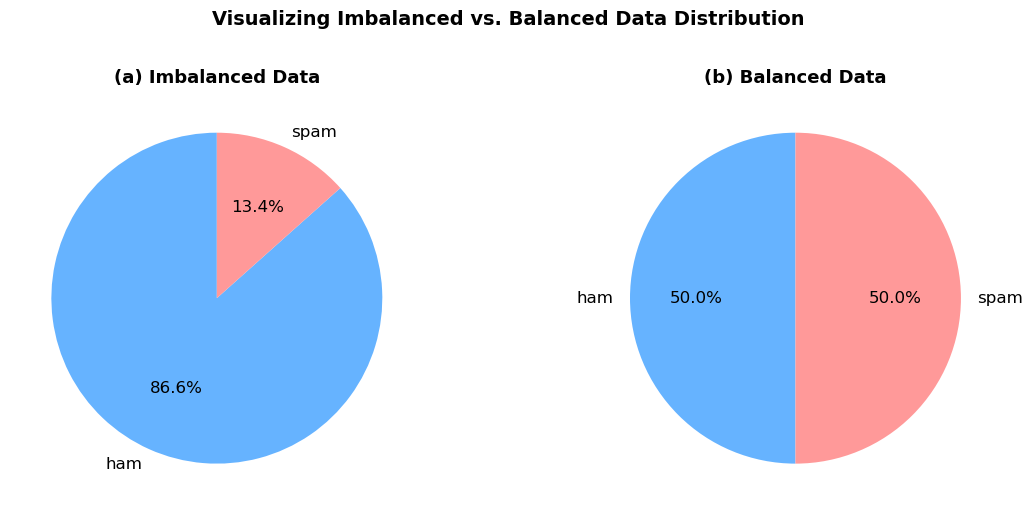

✅ Đã lưu: outputs/data_distribution.png


In [11]:
# ============================================================
# FIGURE 3 — Imbalanced vs Balanced Data Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Imbalanced
label_counts = df['label'].value_counts()
axes[0].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999'],
    startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('(a) Imbalanced Data', fontsize=13, fontweight='bold')

# (b) Balanced — sau oversampling (4825 ham + 4825 spam)
axes[1].pie(
    [4825, 4825],
    labels=['ham', 'spam'],
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999'],
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('(b) Balanced Data', fontsize=13, fontweight='bold')

plt.suptitle(
    'Visualizing Imbalanced vs. Balanced Data Distribution',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('outputs/data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: outputs/data_distribution.png")

In [12]:
# ============================================================
# SPLIT DỮ LIỆU MẤT CÂN BẰNG (IMBALANCED) — 80/20
# Bài báo: 4457 train, 1115 test (từ 5574 mẫu)
# ============================================================

X = df['message_clean']
y = df['label_num']

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"📊 IMBALANCED DATASET:")
print(f"   Train: {len(X_train_imb)} mẫu")
print(f"   Test : {len(X_test_imb)} mẫu")
print(f"   Train spam: {y_train_imb.sum()} | Train ham: {(y_train_imb==0).sum()}")
print(f"   Test  spam: {y_test_imb.sum()}  | Test  ham: {(y_test_imb==0).sum()}")

# TF-IDF Vectorization
tfidf_imb = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_imb_tfidf = tfidf_imb.fit_transform(X_train_imb)
X_test_imb_tfidf  = tfidf_imb.transform(X_test_imb)

print(f"\n✅ TF-IDF shape: train={X_train_imb_tfidf.shape}, test={X_test_imb_tfidf.shape}")

📊 IMBALANCED DATASET:
   Train: 4457 mẫu
   Test : 1115 mẫu
   Train spam: 598 | Train ham: 3859
   Test  spam: 149  | Test  ham: 966

✅ TF-IDF shape: train=(4457, 5000), test=(1115, 5000)


In [13]:
# ============================================================
# HUẤN LUYỆN 4 ML MODELS — IMBALANCED
# Bài báo: XGB, SVM, KNN, RF
# ============================================================

models_dict = {
    'XGB': XGBClassifier(
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    ),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RF' : RandomForestClassifier(n_estimators=100, random_state=42)
}

results_imb = {}
cms_imb = {}
trained_models_imb = {}

print("=" * 65)
print("KẾT QUẢ TRÊN DỮ LIỆU MẤT CÂN BẰNG (IMBALANCED)")
print("=" * 65)

for name, model in models_dict.items():
    print(f"\n⏳ Đang huấn luyện {name}...", end=" ")
    model.fit(X_train_imb_tfidf, y_train_imb)
    y_pred = model.predict(X_test_imb_tfidf)

    acc  = accuracy_score(y_test_imb, y_pred) * 100
    prec = precision_score(y_test_imb, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test_imb, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test_imb, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test_imb, y_pred)

    results_imb[name] = {
        'Accuracy(%)': round(acc, 2),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4)
    }
    cms_imb[name] = cm
    trained_models_imb[name] = model

    print(f"✅ Done!")
    print(f"   Accuracy : {acc:.2f}%")
    print(f"   Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"   Confusion Matrix:\n   {cm}")

KẾT QUẢ TRÊN DỮ LIỆU MẤT CÂN BẰNG (IMBALANCED)

⏳ Đang huấn luyện XGB... ✅ Done!
   Accuracy : 97.67%
   Precision: 0.9769 | Recall: 0.9767 | F1: 0.9759
   Confusion Matrix:
   [[964   2]
 [ 24 125]]

⏳ Đang huấn luyện SVM... ✅ Done!
   Accuracy : 98.21%
   Precision: 0.9823 | Recall: 0.9821 | F1: 0.9816
   Confusion Matrix:
   [[965   1]
 [ 19 130]]

⏳ Đang huấn luyện KNN... ✅ Done!
   Accuracy : 92.20%
   Precision: 0.9270 | Recall: 0.9220 | F1: 0.9080
   Confusion Matrix:
   [[965   1]
 [ 86  63]]

⏳ Đang huấn luyện RF... ✅ Done!
   Accuracy : 97.76%
   Precision: 0.9781 | Recall: 0.9776 | F1: 0.9767
   Confusion Matrix:
   [[966   0]
 [ 25 124]]


In [14]:
# ============================================================
# TABLE 2 — Confusion Matrix Imbalanced (như bài báo)
# ============================================================

print("\n" + "="*75)
print("TABLE 2: Confusion Matrix — Imbalanced Dataset")
print("="*75)
print(f"{'Model':<8} | {'ham→ham':>9} {'ham→spam':>10} | {'spam→ham':>10} {'spam→spam':>11}")
print("-"*75)
for name in models_dict.keys():
    cm = cms_imb[name]
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    print(f"{name:<8} | {tn:>9} {fp:>10} | {fn:>10} {tp:>11}")
print("="*75)
print("(ham→ham=TN, ham→spam=FP, spam→ham=FN, spam→spam=TP)")


TABLE 2: Confusion Matrix — Imbalanced Dataset
Model    |   ham→ham   ham→spam |   spam→ham   spam→spam
---------------------------------------------------------------------------
XGB      |       964          2 |         24         125
SVM      |       965          1 |         19         130
KNN      |       965          1 |         86          63
RF       |       966          0 |         25         124
(ham→ham=TN, ham→spam=FP, spam→ham=FN, spam→spam=TP)


In [15]:
# ============================================================
# TABLE 3 — Per-class Precision/Recall/F1 (Imbalanced)
# ============================================================

print("\n" + "="*65)
print("TABLE 3: Precision, Recall, F1-Score — Imbalanced Dataset")
print("="*65)
print(f"{'Model':<10} {'Class':<8} {'Precision':>10} {'Recall':>8} {'F1-score':>10}")
print("-"*65)

for name, model in trained_models_imb.items():
    y_pred = model.predict(X_test_imb_tfidf)
    # ham (class 0)
    p_ham = precision_score(y_test_imb, y_pred, pos_label=0, average='binary', zero_division=0)
    r_ham = recall_score(y_test_imb, y_pred, pos_label=0, average='binary', zero_division=0)
    f_ham = f1_score(y_test_imb, y_pred, pos_label=0, average='binary', zero_division=0)
    # spam (class 1)
    p_sp  = precision_score(y_test_imb, y_pred, pos_label=1, average='binary', zero_division=0)
    r_sp  = recall_score(y_test_imb, y_pred, pos_label=1, average='binary', zero_division=0)
    f_sp  = f1_score(y_test_imb, y_pred, pos_label=1, average='binary', zero_division=0)

    print(f"{name:<10} {'ham':<8} {p_ham:>10.2f} {r_ham:>8.2f} {f_ham:>10.2f}")
    print(f"{'':<10} {'spam':<8} {p_sp:>10.2f} {r_sp:>8.2f} {f_sp:>10.2f}")
    print("-"*65)


TABLE 3: Precision, Recall, F1-Score — Imbalanced Dataset
Model      Class     Precision   Recall   F1-score
-----------------------------------------------------------------
XGB        ham            0.98     1.00       0.99
           spam           0.98     0.84       0.91
-----------------------------------------------------------------
SVM        ham            0.98     1.00       0.99
           spam           0.99     0.87       0.93
-----------------------------------------------------------------
KNN        ham            0.92     1.00       0.96
           spam           0.98     0.42       0.59
-----------------------------------------------------------------
RF         ham            0.97     1.00       0.99
           spam           1.00     0.83       0.91
-----------------------------------------------------------------


In [16]:
# ============================================================
# CÂN BẰNG DỮ LIỆU — Oversampling
# Bài báo dùng Back Translation, ở đây dùng resample thay thế
# Kết quả cuối: 4825 ham + 4825 spam
# ============================================================

df_ham  = df[df['label_num'] == 0].copy()
df_spam = df[df['label_num'] == 1].copy()

print(f"Trước cân bằng — ham: {len(df_ham)}, spam: {len(df_spam)}")

# Oversample spam lên bằng ham (4825 mẫu)
df_spam_oversampled = resample(
    df_spam,
    replace=True,
    n_samples=len(df_ham),
    random_state=42
)

df_balanced = pd.concat([df_ham, df_spam_oversampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Sau cân bằng  — ham: {(df_balanced['label_num']==0).sum()}, spam: {(df_balanced['label_num']==1).sum()}")
print(f"Tổng: {len(df_balanced)} mẫu")

# Split 80/20
X_bal = df_balanced['message_clean']
y_bal = df_balanced['label_num']

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

print(f"\n📊 BALANCED DATASET:")
print(f"   Train: {len(X_train_bal)} mẫu")
print(f"   Test : {len(X_test_bal)} mẫu")

# TF-IDF
tfidf_bal = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bal_tfidf = tfidf_bal.fit_transform(X_train_bal)
X_test_bal_tfidf  = tfidf_bal.transform(X_test_bal)

print(f"\n✅ TF-IDF shape: train={X_train_bal_tfidf.shape}, test={X_test_bal_tfidf.shape}")

Trước cân bằng — ham: 4825, spam: 747
Sau cân bằng  — ham: 4825, spam: 4825
Tổng: 9650 mẫu

📊 BALANCED DATASET:
   Train: 7720 mẫu
   Test : 1930 mẫu

✅ TF-IDF shape: train=(7720, 5000), test=(1930, 5000)


In [17]:
# ============================================================
# HUẤN LUYỆN 4 ML MODELS — BALANCED
# ============================================================

# Khởi tạo lại models (tránh dùng model đã fit trước đó)
models_dict_bal = {
    'XGB': XGBClassifier(
        n_estimators=100, random_state=42,
        use_label_encoder=False, eval_metric='logloss', verbosity=0
    ),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RF' : RandomForestClassifier(n_estimators=100, random_state=42)
}

results_bal = {}
cms_bal = {}
trained_models_bal = {}

print("=" * 65)
print("KẾT QUẢ TRÊN DỮ LIỆU CÂN BẰNG (BALANCED)")
print("=" * 65)

for name, model in models_dict_bal.items():
    print(f"\n⏳ Đang huấn luyện {name}...", end=" ")
    model.fit(X_train_bal_tfidf, y_train_bal)
    y_pred = model.predict(X_test_bal_tfidf)

    acc  = accuracy_score(y_test_bal, y_pred) * 100
    prec = precision_score(y_test_bal, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test_bal, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test_bal, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test_bal, y_pred)

    results_bal[name] = {
        'Accuracy(%)': round(acc, 2),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4)
    }
    cms_bal[name] = cm
    trained_models_bal[name] = model

    print(f"✅ Done!")
    print(f"   Accuracy : {acc:.2f}%")
    print(f"   Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"   Confusion Matrix:\n   {cm}")

KẾT QUẢ TRÊN DỮ LIỆU CÂN BẰNG (BALANCED)

⏳ Đang huấn luyện XGB... ✅ Done!
   Accuracy : 99.74%
   Precision: 0.9974 | Recall: 0.9974 | F1: 0.9974
   Confusion Matrix:
   [[961   4]
 [  1 964]]

⏳ Đang huấn luyện SVM... ✅ Done!
   Accuracy : 99.95%
   Precision: 0.9995 | Recall: 0.9995 | F1: 0.9995
   Confusion Matrix:
   [[965   0]
 [  1 964]]

⏳ Đang huấn luyện KNN... ✅ Done!
   Accuracy : 97.41%
   Precision: 0.9745 | Recall: 0.9741 | F1: 0.9741
   Confusion Matrix:
   [[926  39]
 [ 11 954]]

⏳ Đang huấn luyện RF... ✅ Done!
   Accuracy : 99.95%
   Precision: 0.9995 | Recall: 0.9995 | F1: 0.9995
   Confusion Matrix:
   [[965   0]
 [  1 964]]


In [18]:
# TABLE 5 — Confusion Matrix Balanced
print("\n" + "="*75)
print("TABLE 5: Confusion Matrix — Balanced Dataset")
print("="*75)
print(f"{'Model':<8} | {'ham→ham':>9} {'ham→spam':>10} | {'spam→ham':>10} {'spam→spam':>11}")
print("-"*75)
for name in models_dict_bal.keys():
    cm = cms_bal[name]
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    print(f"{name:<8} | {tn:>9} {fp:>10} | {fn:>10} {tp:>11}")
print("="*75)

# TABLE 6 — Per-class metrics Balanced
print("\n" + "="*65)
print("TABLE 6: Precision, Recall, F1-Score — Balanced Dataset")
print("="*65)
print(f"{'Model':<10} {'Class':<8} {'Precision':>10} {'Recall':>8} {'F1-score':>10}")
print("-"*65)

for name, model in trained_models_bal.items():
    y_pred = model.predict(X_test_bal_tfidf)
    for cls, lbl in [('ham', 0), ('spam', 1)]:
        p = precision_score(y_test_bal, y_pred, pos_label=lbl, average='binary', zero_division=0)
        r = recall_score(y_test_bal, y_pred, pos_label=lbl, average='binary', zero_division=0)
        f = f1_score(y_test_bal, y_pred, pos_label=lbl, average='binary', zero_division=0)
        print(f"{name:<10} {cls:<8} {p:>10.2f} {r:>8.2f} {f:>10.2f}")
    print("-"*65)


TABLE 5: Confusion Matrix — Balanced Dataset
Model    |   ham→ham   ham→spam |   spam→ham   spam→spam
---------------------------------------------------------------------------
XGB      |       961          4 |          1         964
SVM      |       965          0 |          1         964
KNN      |       926         39 |         11         954
RF       |       965          0 |          1         964

TABLE 6: Precision, Recall, F1-Score — Balanced Dataset
Model      Class     Precision   Recall   F1-score
-----------------------------------------------------------------
XGB        ham            1.00     1.00       1.00
XGB        spam           1.00     1.00       1.00
-----------------------------------------------------------------
SVM        ham            1.00     1.00       1.00
SVM        spam           1.00     1.00       1.00
-----------------------------------------------------------------
KNN        ham            0.99     0.96       0.97
KNN        spam           0.96  

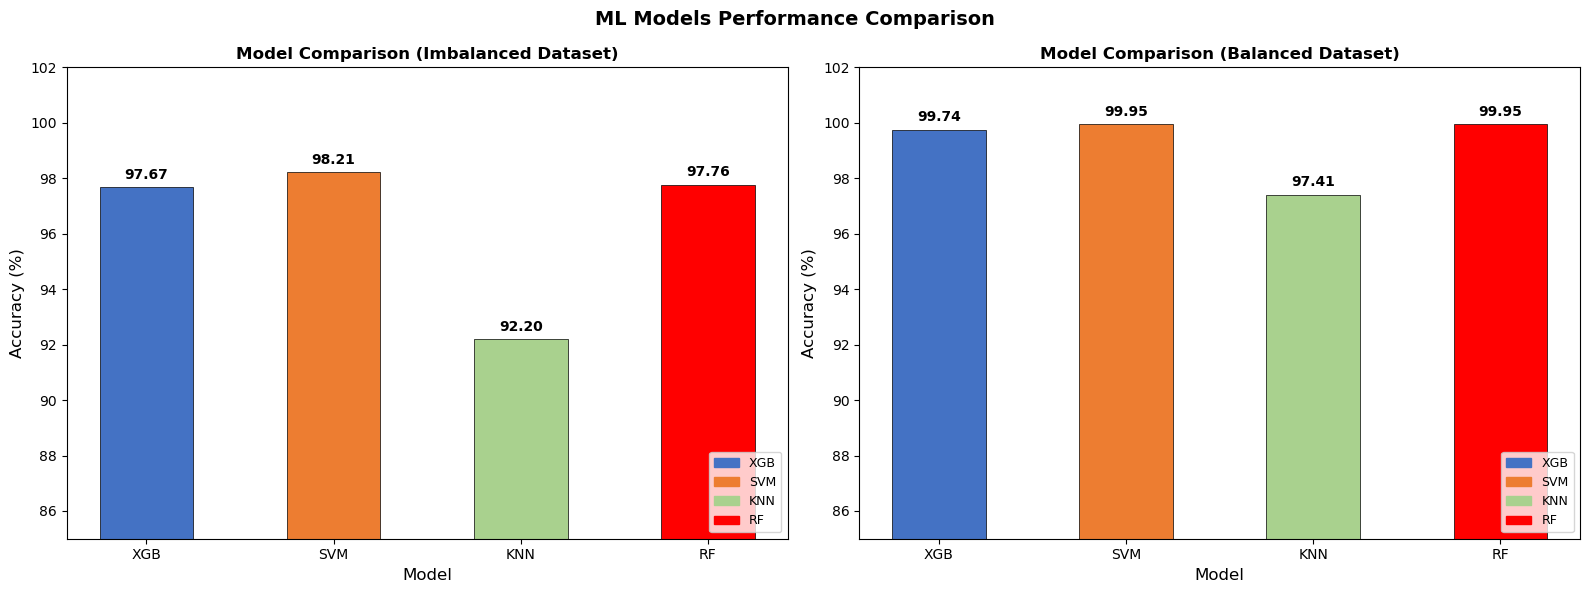

✅ Đã lưu: outputs/ml_comparison.png


In [19]:
# ============================================================
# FIGURE 7 + FIGURE 9 — Bar chart so sánh accuracy
# ============================================================

model_names = list(models_dict.keys())
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, results, title, fig_label in [
    (axes[0], results_imb, 'Imbalanced Dataset', 'Figure 7'),
    (axes[1], results_bal, 'Balanced Dataset',   'Figure 9')
]:
    accs = [results[m]['Accuracy(%)'] for m in model_names]
    bars = ax.bar(model_names, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

    ax.set_ylim(85, 102)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_title(f'Model Comparison ({title})', fontsize=12, fontweight='bold')

    for bar, acc in zip(bars, accs):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{acc:.2f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

    ax.legend(
        [plt.Rectangle((0,0),1,1, color=c) for c in colors],
        model_names,
        loc='lower right', fontsize=9
    )

plt.suptitle('ML Models Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: outputs/ml_comparison.png")

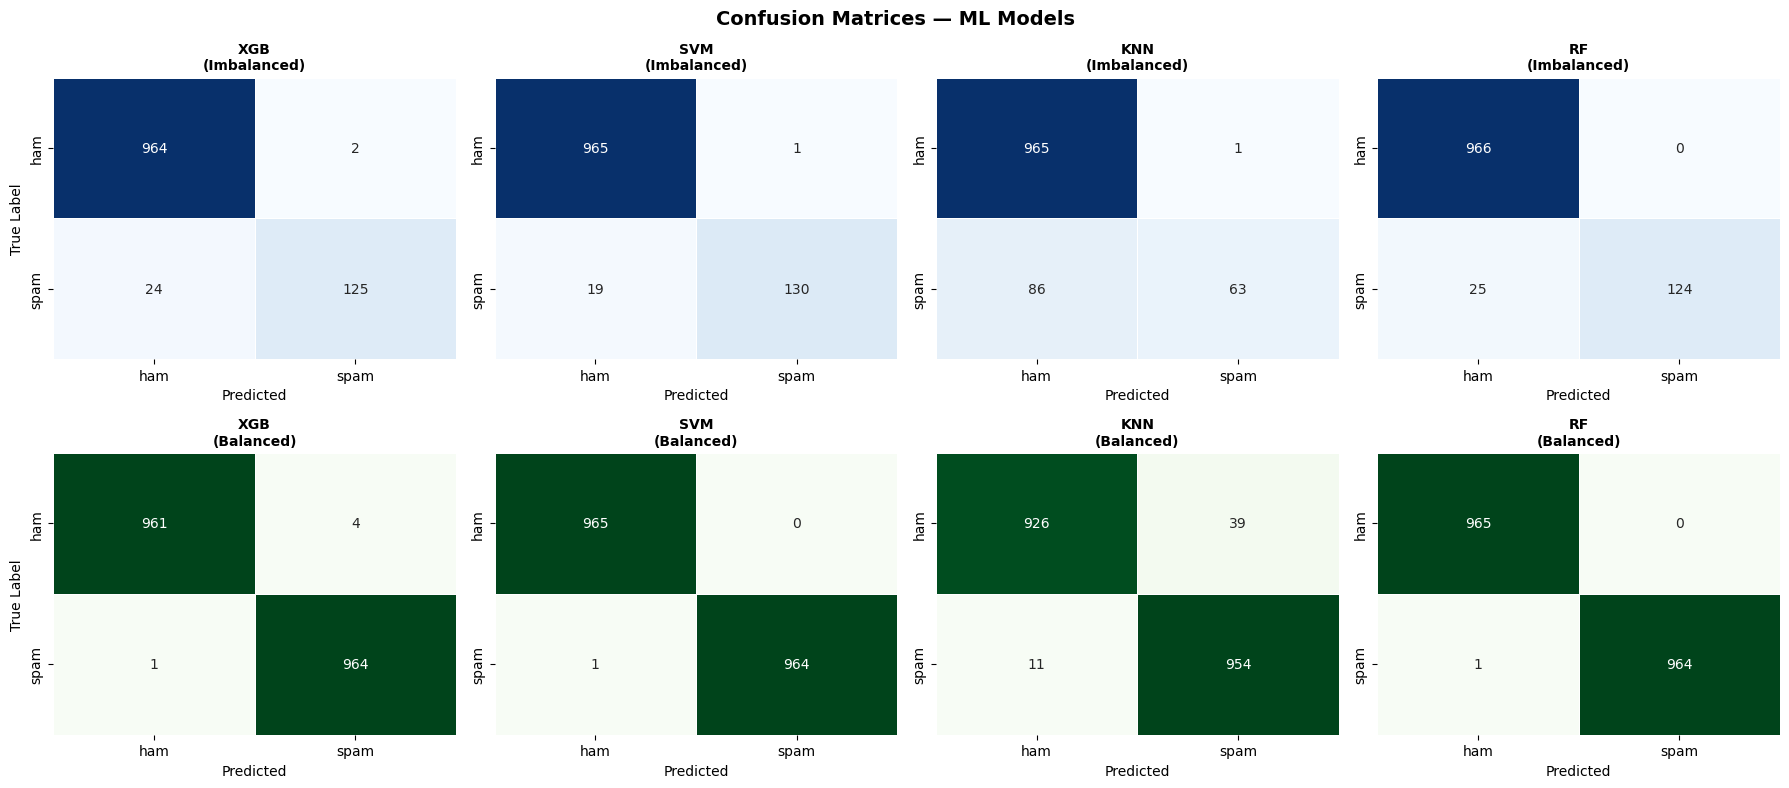

✅ Đã lưu: outputs/confusion_matrices.png


In [20]:
# ============================================================
# CONFUSION MATRIX HEATMAP — 4 models × 2 datasets
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
titles_top = [f"{n}\n(Imbalanced)" for n in model_names]
titles_bot = [f"{n}\n(Balanced)"   for n in model_names]

for col, name in enumerate(model_names):
    # Imbalanced
    sns.heatmap(
        cms_imb[name], annot=True, fmt='d', cmap='Blues',
        xticklabels=['ham','spam'], yticklabels=['ham','spam'],
        ax=axes[0][col], linewidths=0.5, cbar=False
    )
    axes[0][col].set_title(titles_top[col], fontsize=10, fontweight='bold')
    axes[0][col].set_ylabel('True Label' if col==0 else '')
    axes[0][col].set_xlabel('Predicted')

    # Balanced
    sns.heatmap(
        cms_bal[name], annot=True, fmt='d', cmap='Greens',
        xticklabels=['ham','spam'], yticklabels=['ham','spam'],
        ax=axes[1][col], linewidths=0.5, cbar=False
    )
    axes[1][col].set_title(titles_bot[col], fontsize=10, fontweight='bold')
    axes[1][col].set_ylabel('True Label' if col==0 else '')
    axes[1][col].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — ML Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: outputs/confusion_matrices.png")

In [21]:
# ============================================================
# BẢNG TỔNG HỢP CUỐI + LƯU CSV
# ============================================================

rows = []
for name in model_names:
    for dataset, results in [('Imbalanced', results_imb), ('Balanced', results_bal)]:
        row = {'Model': name, 'Dataset': dataset}
        row.update(results[name])
        rows.append(row)

df_results = pd.DataFrame(rows)
df_results.to_csv('outputs/results_table.csv', index=False)

print("\n" + "="*75)
print("BẢNG TỔNG HỢP KẾT QUẢ GIAI ĐOẠN 1 — ML MODELS")
print("="*75)
print(df_results.to_string(index=False))

print("\n✅ ĐÃ LƯU: outputs/results_table.csv")
print("\n📁 CÁC FILE ĐÃ TẠO:")
for f in os.listdir('outputs'):
    size = os.path.getsize(f'outputs/{f}')
    print(f"   outputs/{f}  ({size/1024:.1f} KB)")

print("\n🎉 HOÀN THÀNH GIAI ĐOẠN 1!")


BẢNG TỔNG HỢP KẾT QUẢ GIAI ĐOẠN 1 — ML MODELS
Model    Dataset  Accuracy(%)  Precision  Recall  F1-score
  XGB Imbalanced        97.67     0.9769  0.9767    0.9759
  XGB   Balanced        99.74     0.9974  0.9974    0.9974
  SVM Imbalanced        98.21     0.9823  0.9821    0.9816
  SVM   Balanced        99.95     0.9995  0.9995    0.9995
  KNN Imbalanced        92.20     0.9270  0.9220    0.9080
  KNN   Balanced        97.41     0.9745  0.9741    0.9741
   RF Imbalanced        97.76     0.9781  0.9776    0.9767
   RF   Balanced        99.95     0.9995  0.9995    0.9995

✅ ĐÃ LƯU: outputs/results_table.csv

📁 CÁC FILE ĐÃ TẠO:
   outputs/confusion_matrices.png  (77.5 KB)
   outputs/data_distribution.png  (63.4 KB)
   outputs/ml_comparison.png  (70.3 KB)
   outputs/results_table.csv  (0.4 KB)

🎉 HOÀN THÀNH GIAI ĐOẠN 1!
